# Discharge reconstruction during data gaps 2022-2023

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

lajara_2022 = pd.read_csv("../la_jara/shear_stress_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # Pa
lajara_2023 = pd.read_csv("../la_jara/shear_stress_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # Pa

san_antonio = pd.read_csv("../san_antonio/DataSetExport-Discharge.Discharge@VALL_RSAWES-Maximum-ft^3 s-20260302191152.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
lower_sulphur = pd.read_csv("../lower_sulphur/DataSetExport-Discharge.Discharge (Daily Mean)@VALL_LWRSUL-Maximum-ft^3 s-20260302190628.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
upper_sulphur = pd.read_csv("../upper_sulphur/DataSetExport-Discharge.Discharge@VALL_UPRSUL-Maximum-ft^3 s-20260302181951.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
redondo = pd.read_csv("../redondo/DataSetExport-Discharge.Discharge@VALL_MIRLKE-Maximum-ft^3 s-20260223140410.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s

# convert ft^3/s to m3/s for san_antonio, lower_sulphur, and upper_sulphur
san_antonio["san_antonio (m3/s)"] = san_antonio["Value (ft^3/s)"] * 0.0283168
redondo["redondo (m3/s)"] = redondo["Value (ft^3/s)"] * 0.0283168
lower_sulphur["lower_sulphur (m3/s)"] = lower_sulphur["Value (ft^3/s)"] * 0.0283168
upper_sulphur["upper_sulphur (m3/s)"] = upper_sulphur["Value (ft^3/s)"] * 0.0283168

# la jara data as base 
lajara_2022.rename(columns={'0': 'la_jara'}, inplace=True)
lajara_2023.rename(columns={'0': 'la_jara'}, inplace=True)

# remove timezone info from all indices to enable joining
lajara_2022.index = lajara_2022.index.tz_localize(None) if lajara_2022.index.tz is not None else lajara_2022.index
lajara_2023.index = lajara_2023.index.tz_localize(None) if lajara_2023.index.tz is not None else lajara_2023.index
redondo.index = redondo.index.tz_localize(None) if redondo.index.tz is not None else redondo.index
san_antonio.index = san_antonio.index.tz_localize(None) if san_antonio.index.tz is not None else san_antonio.index
lower_sulphur.index = lower_sulphur.index.tz_localize(None) if lower_sulphur.index.tz is not None else lower_sulphur.index
upper_sulphur.index = upper_sulphur.index.tz_localize(None) if upper_sulphur.index.tz is not None else upper_sulphur.index

Only keep data from 2022 and 2023 

In [5]:
# only keep data from 2022 and 2023
san_antonio = san_antonio[(san_antonio.index.year >= 2022) & (san_antonio.index.year <= 2023)]
redondo = redondo[(redondo.index.year >= 2022) & (redondo.index.year <= 2023)]
lower_sulphur = lower_sulphur[(lower_sulphur.index.year >= 2022) & (lower_sulphur.index.year <= 2023)]
upper_sulphur = upper_sulphur[(upper_sulphur.index.year >= 2022) & (upper_sulphur.index.year <= 2023)]

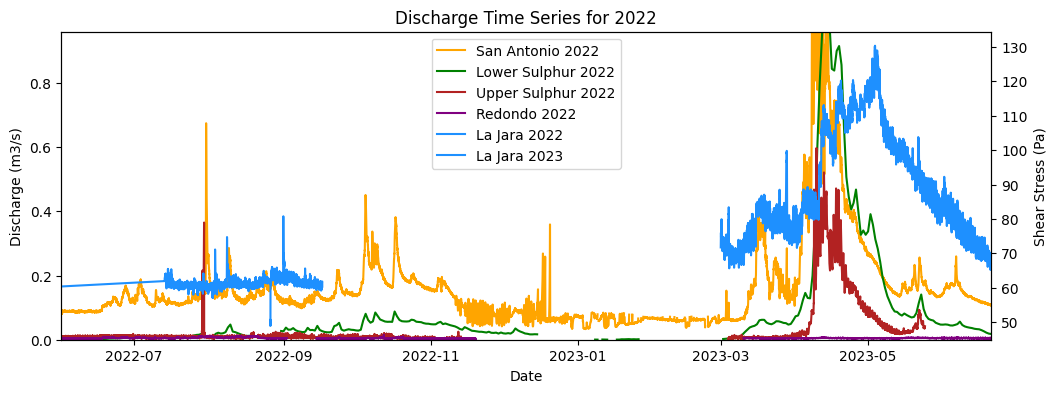

In [7]:
# plot discharge time series for all 4 sites
# 2022
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(san_antonio.index, san_antonio['san_antonio (m3/s)'], label='San Antonio 2022', color='orange')
ax.plot(lower_sulphur.index, lower_sulphur['lower_sulphur (m3/s)'], label='Lower Sulphur 2022', color='green')
ax.plot(upper_sulphur.index, upper_sulphur['upper_sulphur (m3/s)'], label='Upper Sulphur 2022', color='firebrick')
ax.plot(redondo.index, redondo['redondo (m3/s)'], label='Redondo 2022', color='purple')
ax.set_ylabel('Discharge (m3/s)')


ax2 = ax.twinx()
ax2.plot(lajara_2022.index, lajara_2022['la_jara'], label='La Jara 2022', color='dodgerblue')
ax2.plot(lajara_2023.index, lajara_2023['la_jara'], label='La Jara 2023', color= 'dodgerblue')
ax2.set_ylabel('Shear Stress (Pa)')  

# combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax.set_ylim(0, 0.96)
ax.set_title('Discharge Time Series for 2022')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-06-01'), pd.Timestamp('2023-06-21'))
plt.show()

## Using San Antonio - Full Data Gap

In [23]:
lajara_full = pd.concat([lajara_2022, lajara_2023]).sort_index()
lajara_sanantonio = lajara_full.join(san_antonio['san_antonio (m3/s)'], how='outer')
gap_start = pd.Timestamp('2022-09-17')
gap_end = pd.Timestamp('2023-03-01')
gap_mask = (lajara_sanantonio.index >= gap_start) & (lajara_sanantonio.index <= gap_end)

# calculate shear stress using rating curve
#lajara_sanantonio['estimated_tau'] = 21.425 * lajara_sanantonio['san_antonio (m3/s)'] + 58.524 # linear 
lajara_sanantonio['estimated_tau'] =19.616 * np.log(107.677 * lajara_sanantonio['san_antonio (m3/s)']) # logarithmic

lajara_sanantonio.loc[gap_mask & lajara_sanantonio['la_jara'].isna(), 'la_jara'] = lajara_sanantonio.loc[gap_mask & lajara_sanantonio['la_jara'].isna(), 'estimated_tau']

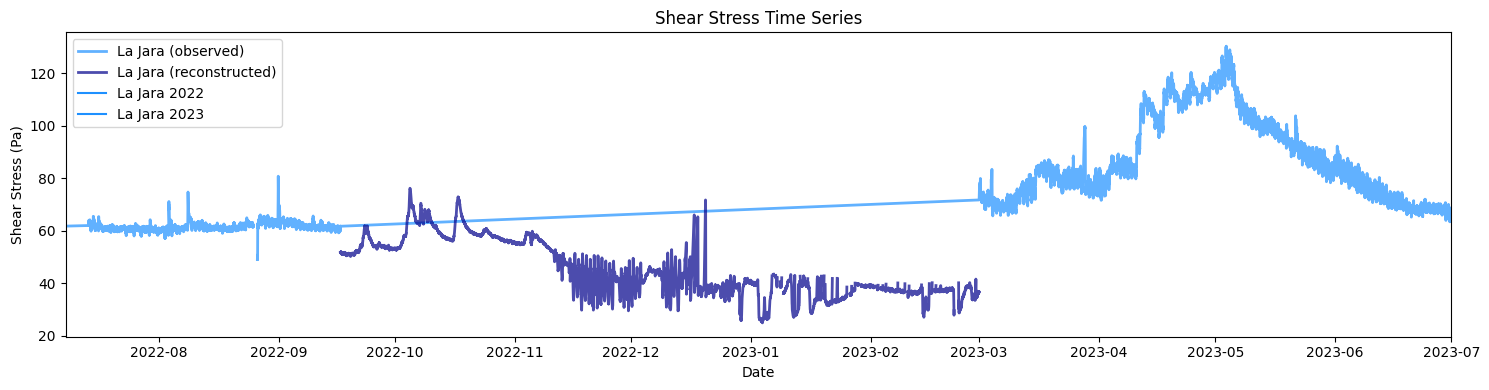

In [24]:
fig, ax = plt.subplots(figsize=(15, 4))

# plot original La Jara data (both years)
ax.plot(lajara_full.index, lajara_full['la_jara'], 
        label='La Jara (observed)', color='dodgerblue', linewidth=2, alpha=0.7)
# plot bias-corrected reconstructed discharge
ax.plot(lajara_sanantonio.loc[gap_mask].index, lajara_sanantonio.loc[gap_mask, 'estimated_tau'], 
        label='La Jara (reconstructed)', color='darkblue', linestyle='-', linewidth=2, alpha=0.7)

ax.set_ylabel('Shear Stress (Pa)')

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax.set_title('Shear Stress Time Series')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-07-08'), pd.Timestamp('2023-07-01'))
plt.tight_layout()
plt.show()

### Smooth Nov-Feb ice noise
This smooths only the likely ice-affected period (Nov-Feb) and keeps all other dates unchanged.

Method:
1. Time interpolation inside the target period
2. Median smoother (robust to spikes)
3. Mean smoother (gentle final smoothing)

In [19]:
# smooth only the likely ice-affected period (Nov-Feb)
ice_start = pd.Timestamp('2022-11-01')
ice_end = pd.Timestamp('2023-03-01 23:59:59')

# choose source series (prefer corrected reconstruction if present)
if 'la_jara_adjusted' in lajara_sanantonio.columns:
    source_col = 'la_jara_adjusted'
else:
    source_col = 'la_jara'

la_jara_smoothed = lajara_sanantonio[source_col].copy()
ice_mask = (lajara_sanantonio.index >= ice_start) & (lajara_sanantonio.index <= ice_end)

# work only inside Nov-Feb window
segment = la_jara_smoothed.loc[ice_mask].copy()
# fill short gaps for stable smoothing
segment_interp = segment.interpolate(method='time', limit_direction='both')

# robust two-stage smoothing:
# 1) median filter removes spikes
# 2) mean filter softens residual jitter
segment_smooth = (
    segment_interp
    .rolling('18h', center=True, min_periods=1).median()
    .rolling('8h', center=True, min_periods=1).mean()
)

# replace only Nov-Feb values
la_jara_smoothed.loc[ice_mask] = segment_smooth
lajara_sanantonio['la_jara_smoothed_ice'] = la_jara_smoothed

print(f"Smoothed period: {ice_start.date()} to {ice_end.date()}")
print(f"Input column: {source_col}")
print("Created column: la_jara_smoothed_ice")

Smoothed period: 2022-11-01 to 2023-03-01
Input column: la_jara_adjusted
Created column: la_jara_smoothed_ice


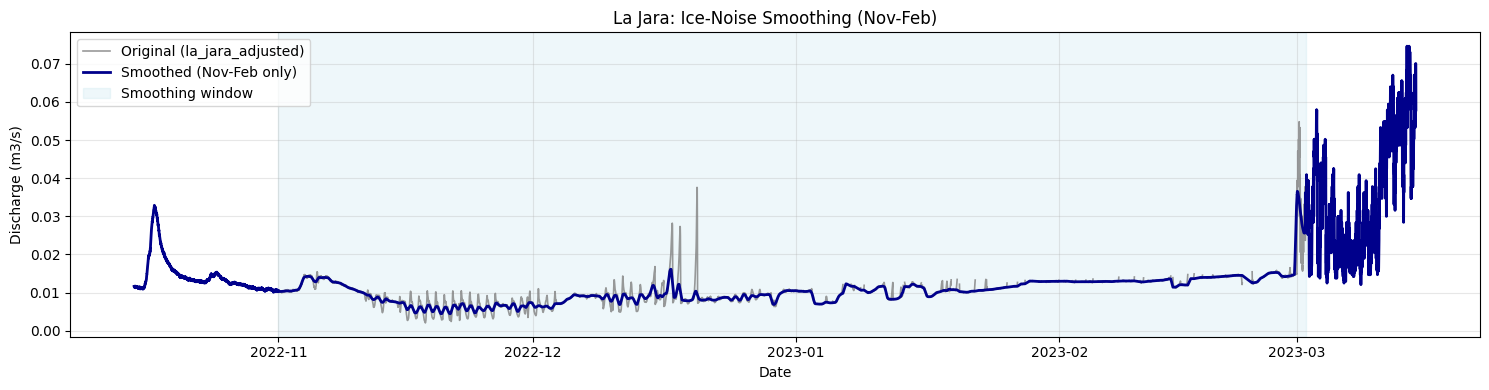

In [20]:
# quick before/after check for Nov-Feb
fig, ax = plt.subplots(figsize=(15, 4))

plot_start = pd.Timestamp('2022-10-15')
plot_end = pd.Timestamp('2023-03-15')
plot_mask = (lajara_sanantonio.index >= plot_start) & (lajara_sanantonio.index <= plot_end)

ax.plot(
    lajara_sanantonio.index[plot_mask],
    lajara_sanantonio.loc[plot_mask, source_col],
    label=f'Original ({source_col})',
    color='gray',
    linewidth=1.2,
    alpha=0.8
)
ax.plot(
    lajara_sanantonio.index[plot_mask],
    lajara_sanantonio.loc[plot_mask, 'la_jara_smoothed_ice'],
    label='Smoothed (Nov-Feb only)',
    color='darkblue',
    linewidth=2.0
)

ax.axvspan(ice_start, ice_end, color='lightblue', alpha=0.2, label='Smoothing window')
ax.set_title('La Jara: Ice-Noise Smoothing (Nov-Feb)')
ax.set_xlabel('Date')
ax.set_ylabel('Discharge (m3/s)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

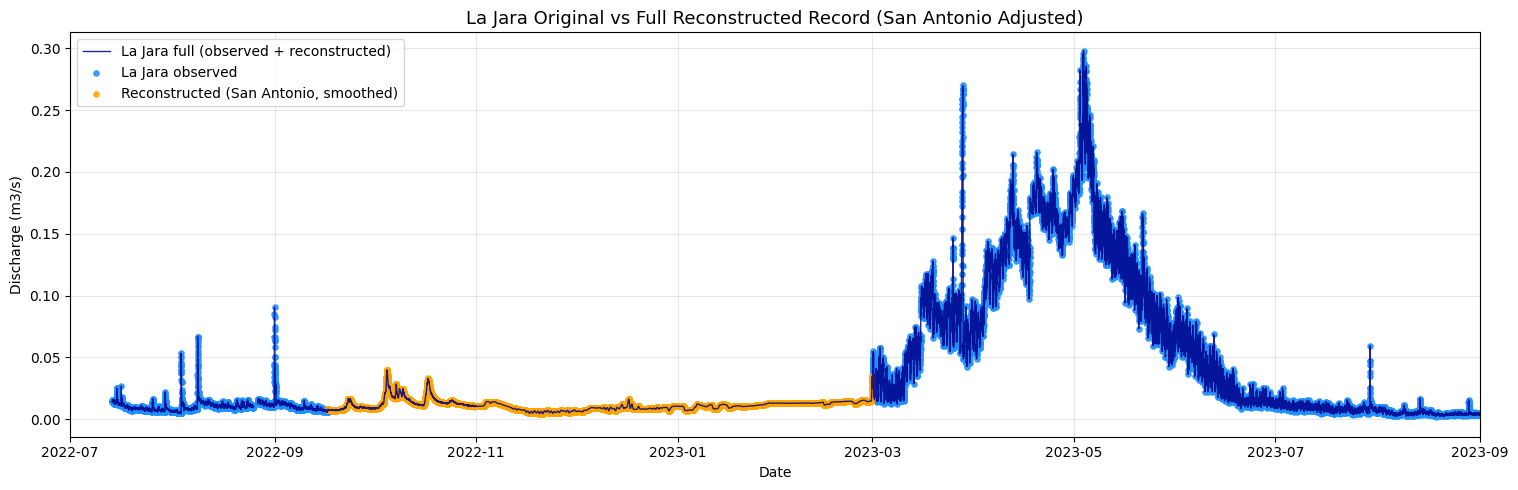

In [21]:
# build final full record using San Antonio bias-corrected + Nov-Feb smoothed reconstruction
obs_2022 = lajara_2022['la_jara'].groupby(level=0).mean()
obs_2023 = lajara_2023['la_jara'].groupby(level=0).mean()
observed_la_jara = pd.concat([obs_2022, obs_2023]).groupby(level=0).mean()

# choose best available San Antonio reconstruction column
if 'la_jara_smoothed_ice' in lajara_sanantonio.columns:
    san_recon_series = lajara_sanantonio['la_jara_smoothed_ice'].groupby(level=0).mean()
elif 'la_jara_adjusted' in lajara_sanantonio.columns:
    san_recon_series = lajara_sanantonio['la_jara_adjusted'].groupby(level=0).mean()
else:
    san_recon_series = lajara_sanantonio['la_jara'].groupby(level=0).mean()

full_index = observed_la_jara.index.union(san_recon_series.index).sort_values()

lajara_full_san = pd.DataFrame(index=full_index)
lajara_full_san['la_jara_observed'] = observed_la_jara
lajara_full_san['la_jara_san_recon'] = san_recon_series

# keep observed where available, fill only gaps with San Antonio reconstruction
lajara_full_san['la_jara_full'] = (
    lajara_full_san['la_jara_observed']
    .combine_first(lajara_full_san['la_jara_san_recon'])
)

fig, ax = plt.subplots(figsize=(15, 5))

# full record after filling gaps
ax.plot(
    lajara_full_san.index,
    lajara_full_san['la_jara_full'],
    color='darkblue',
    linewidth=1,
    alpha=0.85,
    label='La Jara full (observed + reconstructed)'
)

# original observed data only
ax.scatter(
    lajara_full_san.index,
    lajara_full_san['la_jara_observed'],
    color='dodgerblue',
    s=14,
    alpha=0.85,
    label='La Jara observed'
)

# highlight reconstructed points from San Antonio
san_fill_mask = (
    lajara_full_san['la_jara_observed'].isna()
    & lajara_full_san['la_jara_san_recon'].notna()
    & lajara_full_san['la_jara_full'].notna()
)
ax.scatter(
    lajara_full_san.index[san_fill_mask],
    lajara_full_san.loc[san_fill_mask, 'la_jara_full'],
    s=14,
    color='orange',
    alpha=0.85,
    label='Reconstructed (San Antonio, smoothed)'
)

ax.set_title('La Jara Original vs Full Reconstructed Record (San Antonio Adjusted)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Discharge (m3/s)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.xlim(pd.Timestamp('2022-07-01'), pd.Timestamp('2023-09-01'))
plt.show()

## Plot all together

In [22]:
obs_2022 = lajara_2022['la_jara'].groupby(level=0).mean()
obs_2023 = lajara_2023['la_jara'].groupby(level=0).mean()
observed_la_jara = pd.concat([obs_2022, obs_2023]).groupby(level=0).mean()

# reconstruction series from each source
redondo_recon = reconstructed_hydro['la_jara_hydro'].groupby(level=0).mean()
jemez_recon = lajara_jemez['la_jara'].groupby(level=0).mean()

# choose best available San Antonio reconstruction column
if 'la_jara_smoothed_ice' in lajara_sanantonio.columns:
    san_recon = lajara_sanantonio['la_jara_smoothed_ice'].groupby(level=0).mean()
elif 'la_jara_adjusted' in lajara_sanantonio.columns:
    san_recon = lajara_sanantonio['la_jara_adjusted'].groupby(level=0).mean()
else:
    san_recon = lajara_sanantonio['la_jara'].groupby(level=0).mean()

full_index = (
    observed_la_jara.index
    .union(redondo_recon.index)
    .union(san_recon.index)
    .sort_values()
)

combined = pd.DataFrame(index=full_index)
combined['la_jara_observed'] = observed_la_jara
combined['la_jara_redondo'] = redondo_recon
combined['la_jara_jemez'] = jemez_recon
combined['la_jara_san'] = san_recon


combined['la_jara_full'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_redondo'])
    .combine_first(combined['la_jara_san'])
)

redondo_mask = combined['la_jara_observed'].isna() & combined['la_jara_redondo'].notna()
jemez_mask   = combined['la_jara_observed'].isna() & combined['la_jara_jemez'].notna()
san_mask     = combined['la_jara_observed'].isna() & combined['la_jara_san'].notna()

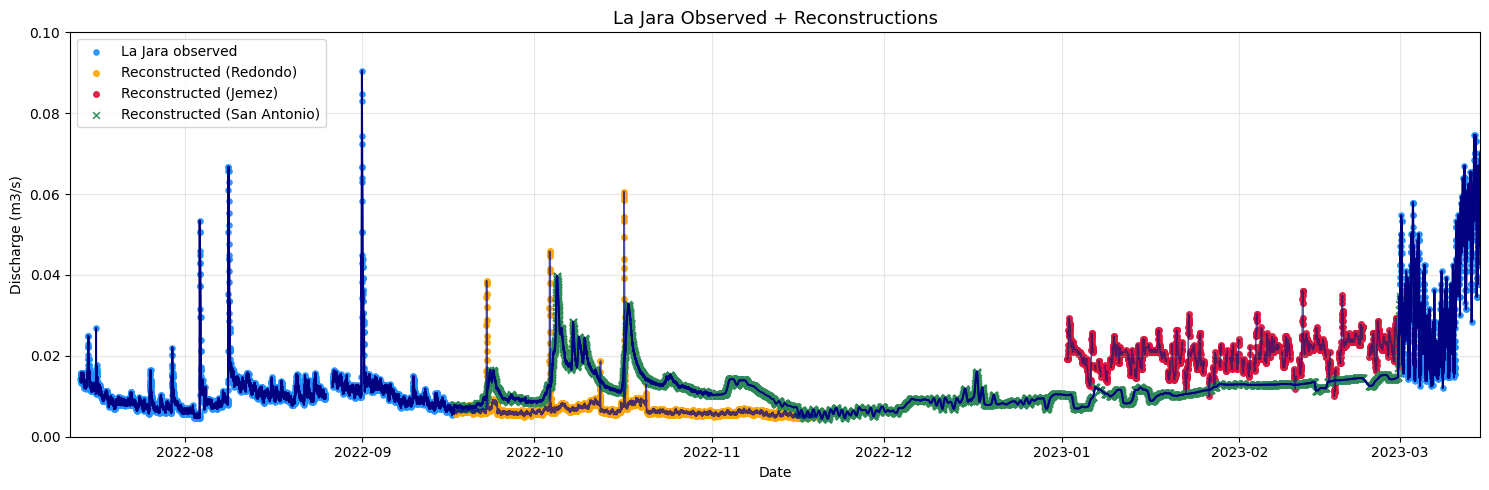

In [23]:
# separate "full" series (observed + one source at a time)
combined['full_redondo'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_redondo'])
)
combined['full_jemez'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_jemez'])
)
combined['full_san'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_san'])
)

# masks (same as before)
redondo_mask = combined['la_jara_observed'].isna() & combined['la_jara_redondo'].notna()
jemez_mask   = combined['la_jara_observed'].isna() & combined['la_jara_jemez'].notna()
san_mask     = combined['la_jara_observed'].isna() & combined['la_jara_san'].notna()

fig, ax = plt.subplots(figsize=(15, 5))

# plot each "full" separately (all dark-blue family, different linestyle)
ax.plot(
    combined.index, combined['full_redondo'],
    color='darkblue', linestyle='-', linewidth=1.2, alpha=0.7)
ax.plot(
    combined.index, combined['full_jemez'],
    color='midnightblue', linestyle='-', linewidth=1.2, alpha=0.7)

san_index = observed_la_jara.index.union(san_recon.index).sort_values()
san_only = pd.DataFrame(index=san_index)
san_only['obs'] = observed_la_jara
san_only['san'] = san_recon
san_only['full_san'] = san_only['obs'].combine_first(san_only['san'])

# plot - no breaks
ax.plot(san_only.index, san_only['full_san'], color='navy', linewidth=1.4)
ax.plot(
    combined.index, combined['full_san'],
    color='navy', linestyle='-', linewidth=1.4, alpha=0.8)

# observed points
ax.scatter(
    combined.index, combined['la_jara_observed'],
    color='dodgerblue', s=14, alpha=0.9, label='La Jara observed'
)

# reconstructed points by source
ax.scatter(
    combined.index[redondo_mask], combined.loc[redondo_mask, 'la_jara_redondo'],
    s=16, color='orange', alpha=0.9, label='Reconstructed (Redondo)'
)
ax.scatter(
    combined.index[jemez_mask], combined.loc[jemez_mask, 'la_jara_jemez'],
    s=16, color='crimson', alpha=0.9, label='Reconstructed (Jemez)'
)
ax.scatter(
    combined.index[san_mask], combined.loc[san_mask, 'la_jara_san'],
    s=24, marker='x', linewidths=1.2, color='seagreen', alpha=0.9,
    label='Reconstructed (San Antonio)'
)

ax.set_title('La Jara Observed + Reconstructions', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Discharge (m3/s)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.set_xlim(pd.Timestamp('2022-07-12'), pd.Timestamp('2023-03-15'))
plt.ylim(0, 0.1)
plt.tight_layout()
plt.show()

## Plot comparison with precipitation and temperature

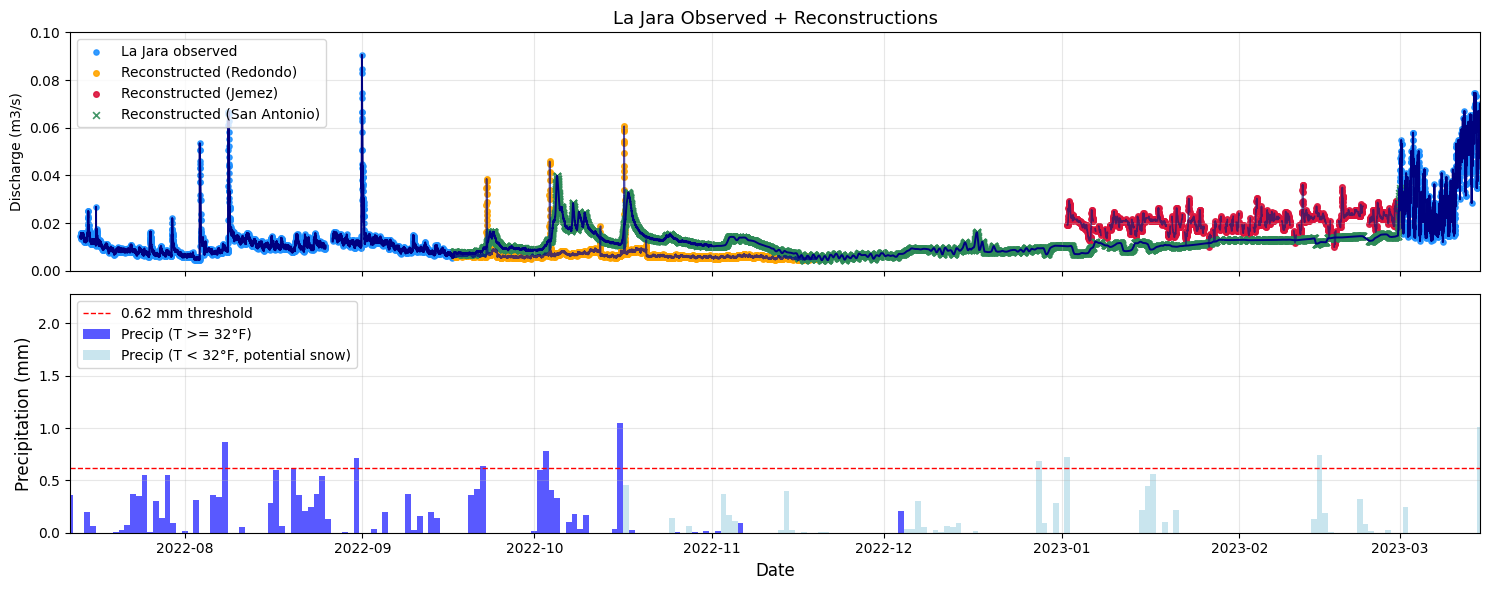

In [24]:
# separate "full" series (observed + one source at a time)
combined['full_redondo'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_redondo'])
)
combined['full_jemez'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_jemez'])
)
combined['full_san'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_san'])
)

# masks (same as before)
redondo_mask = combined['la_jara_observed'].isna() & combined['la_jara_redondo'].notna()
jemez_mask   = combined['la_jara_observed'].isna() & combined['la_jara_jemez'].notna()
san_mask     = combined['la_jara_observed'].isna() & combined['la_jara_san'].notna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
# plot each "full" separately (all dark-blue family, different linestyle)
ax1.plot(
    combined.index, combined['full_redondo'],
    color='darkblue', linestyle='-', linewidth=1.2, alpha=0.7)
ax1.plot(
    combined.index, combined['full_jemez'],
    color='midnightblue', linestyle='-', linewidth=1.2, alpha=0.7)

san_index = observed_la_jara.index.union(san_recon.index).sort_values()
san_only = pd.DataFrame(index=san_index)
san_only['obs'] = observed_la_jara
san_only['san'] = san_recon
san_only['full_san'] = san_only['obs'].combine_first(san_only['san'])

# plot - no breaks
ax1.plot(san_only.index, san_only['full_san'], color='navy', linewidth=1.4)

# observed points
ax1.scatter(
    combined.index, combined['la_jara_observed'],
    color='dodgerblue', s=14, alpha=0.9, label='La Jara observed'
)

# reconstructed points by source
ax1.scatter(
    combined.index[redondo_mask], combined.loc[redondo_mask, 'la_jara_redondo'],
    s=16, color='orange', alpha=0.9, label='Reconstructed (Redondo)'
)
ax1.scatter(
    combined.index[jemez_mask], combined.loc[jemez_mask, 'la_jara_jemez'],
    s=16, color='crimson', alpha=0.9, label='Reconstructed (Jemez)'
)
ax1.scatter(
    combined.index[san_mask], combined.loc[san_mask, 'la_jara_san'],
    s=24, marker='x', linewidths=1.2, color='seagreen', alpha=0.9,
    label='Reconstructed (San Antonio)'
)

ax1.set_title('La Jara Observed + Reconstructions', fontsize=13)
ax1.set_ylabel('Discharge (m3/s)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1.set_ylim(0, 0.1)

# precipitation pannel
# separate precipitation by temperature
precip_warm = precipitation['total_precip'].where(precipitation['avg_temp'] >= 32, 0)
precip_cold = precipitation['total_precip'].where(precipitation['avg_temp'] < 32, 0)

# plot both
ax2.bar(precipitation.index, precip_warm, alpha=0.65, color='blue', width=1, 
        label='Precip (T >= 32°F)')
ax2.bar(precipitation.index, precip_cold, alpha=0.65, color='lightblue', width=1, 
        label='Precip (T < 32°F, potential snow)')
ax2.axhline(y=0.62, color='red', linestyle='--', linewidth=1, label='0.62 mm threshold')
ax2.set_ylabel('Precipitation (mm)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# set x-axis limits for both panels
ax1.set_xlim(pd.Timestamp('2022-07-12'), pd.Timestamp('2023-03-15'))
ax2.set_xlim(pd.Timestamp('2022-07-12'), pd.Timestamp('2023-03-15'))

plt.tight_layout()
plt.show()

In [40]:
# export all reconstructed discharges 
export_cols = ['la_jara_observed', 'la_jara_redondo', 'la_jara_jemez', 'la_jara_san', 'la_jara_full']
# resample to 15 mins 
lajara = combined['la_jara_full'].copy()
lajara = lajara.resample('15min').interpolate(method='time')
# keep data from 07/14/2022 to 09/18/2023
lajara = lajara.loc['2022-07-14':'2023-09-18']

lajara.to_csv('la_jara_reconstructed_discharge_rsa.csv', index_label='timestamp')

In [41]:
# check the time dif in the index in lajara
time_diffs = lajara.index.to_series().diff().dropna()
print("Time differences between consecutive timestamps in reconstructed La Jara:")
print(time_diffs.value_counts())

Time differences between consecutive timestamps in reconstructed La Jara:
0 days 00:15:00    41471
Name: count, dtype: int64


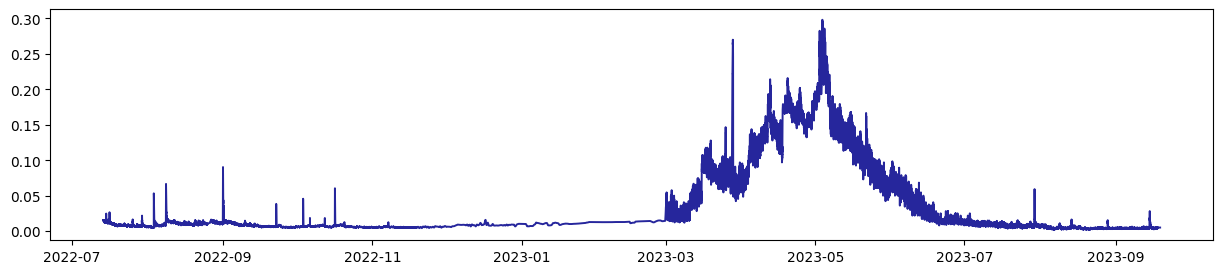

In [42]:
# plot combined la jara full
fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(
    lajara,
    color='darkblue', linewidth=1.4, alpha=0.85, label='La Jara full (observed + reconstructed)'
)
plt.show()

### Saving this for later

In [ ]:
# diagnose the discontinuity
gap_end_date = pd.Timestamp('2023-03-01')
taper_days =120  # apply correction over last 14 days (shorter = more drastic)
correction_multiplier = 3  # multiply discontinuity by this factor (>1.0 = goes higher)

# find first observed value after gap
first_obs_after_gap = lajara_sanantonio[
    (lajara_sanantonio.index >= gap_end_date) & 
    (lajara_sanantonio['la_jara'].notna()) & 
    (lajara_sanantonio['estimated_Q'].isna())
]['la_jara'].first_valid_index()

if first_obs_after_gap is not None:
    first_obs_value = lajara_sanantonio.loc[first_obs_after_gap, 'la_jara']
    
    # find last reconstructed value before observed data resumes
    last_recon_before_obs = lajara_sanantonio[
        (lajara_sanantonio.index < first_obs_after_gap) & 
        (lajara_sanantonio['la_jara'].notna())
    ].iloc[-1]
    
    last_recon_value = last_recon_before_obs['la_jara']
    last_recon_date = last_recon_before_obs.name
    
    # calculate the discontinuity
    discontinuity = first_obs_value - last_recon_value
    correction_amount = discontinuity * correction_multiplier  # amplify the correction
    
    print(f"Last reconstructed value: {last_recon_value:.6f} m³/s on {last_recon_date}")
    print(f"First observed value: {first_obs_value:.6f} m³/s on {first_obs_after_gap}")
    print(f"Discontinuity (gap): {discontinuity:.6f} m³/s ({discontinuity/first_obs_value*100:.1f}% of observed)")
    print(f"Correction multiplier: {correction_multiplier}x → Total correction: {correction_amount:.6f} m³/s")
    
    # Apply tapering correction ONLY at the end of the gap (last N days)
    # This preserves the reconstruction during Oct-Dec, only fixes the end discontinuity
    
    lajara_sanantonio['la_jara_adjusted'] = lajara_sanantonio['la_jara'].copy()
    
    # Apply taper at END of gap (smooth transition to observed data)
    taper_start = last_recon_date - pd.Timedelta(days=taper_days)
    taper_mask = (lajara_sanantonio.index >= taper_start) & (lajara_sanantonio.index <= last_recon_date)
    
    taper_subset = lajara_sanantonio[taper_mask].copy()
    n_taper_points = len(taper_subset)
    
    for i in range(n_taper_points):
        if pd.notna(taper_subset.iloc[i]['la_jara']):
            # taper from 0 to 1 (gradually introduce the correction)
            weight = (i + 1) / n_taper_points
            correction = correction_amount * weight
            taper_subset.iloc[i, taper_subset.columns.get_loc('la_jara_adjusted')] += correction
    
    lajara_sanantonio.loc[taper_mask, 'la_jara_adjusted'] = taper_subset['la_jara_adjusted']
    
    print(f"\nApplied bias correction with {taper_days}-day taper at end of gap")
    print(f"Taper period: {taper_start} to {last_recon_date}")
    print(f"Correction range: 0% → 100% (max: {correction_amount:.6f} m³/s)")
else:
    print("Could not find observed data after gap to calculate discontinuity")
    lajara_sanantonio['la_jara_adjusted'] = lajara_sanantonio['la_jara'].copy()